# firelab — Architecture

**D7065E — Embedded Intelligence at the Edge**

firelab is a fire-detection and autonomous-response system that runs against
**BuildSim**, a building model with a 3D viewer. BuildSim stores the building and
draws it; it does not simulate anything. firelab supplies everything else: fire
physics, emulated sensors, detection, an alarm state machine, safety interlocks,
actuators, evacuation and scoring. It writes the results back to BuildSim so they
appear in the 3D view.

This document describes **what is implemented in the code today**. Every constant
and rule quoted here comes from the source files it names.

| § | Section | Main files |
|---|---|---|
| 1 | System context | `app/main.py`, `adapters/buildsim/` |
| 2 | The control loop | `app/engine/core.py` |
| 3 | Layers and the dependency rule | `domain/`, `adapters/`, `app/`, `tests/test_layering.py` |
| 4 | Startup and one tick | `app/engine/building.py`, `core.py` |
| 5 | WORLD — sources and physics | `domain/sources.py`, `world.py`, `physics.py`, `adapters/world_builder.py` |
| 6 | SENSING — emulated devices | `domain/sensing.py`, `app/engine/devices.py`, `truth.py` |
| 7 | INTELLIGENCE — features, detector, agent | `domain/features.py`, `detector.py`, `agent.py`, `app/engine/intelligence.py` |
| 8 | ACTION — interlocks and actuation | `domain/interlocks.py`, `app/engine/actuation.py` |
| 9 | Occupants and evacuation | `domain/roles.py`, `occupants.py`, `app/evacuation.py` |
| 10 | Life safety and evaluation | `domain/tenability.py`, `scoring.py`, `timeline.py`, `history.py` |
| 11 | Publishing to BuildSim | `app/engine/publishing.py`, `adapters/publisher/` |
| 12 | HTTP API, snapshot and UI | `app/api/`, `app/snapshot/`, `ui/` |
| 13 | Configuration and presets | `app/config.py`, `app/presets.py` |
| 14 | State, concurrency and reset | `app/engine/state.py`, `session.py` |
| 15 | Tests | `tests/` |
| 16 | Known limitations | — |

Colours are the same in every diagram:
🟥 **world** (ground truth) · 🟨 **sensing** (readings) · 🟦 **intelligence** (decisions) · 🟩 **action** (effects)

In [ ]:
"""Render Mermaid source as an inline SVG. Every diagram below is already rendered;
run this only if you edit one. Needs internet (mermaid.ink)."""

import base64
import urllib.request

from IPython.display import SVG, Markdown, display


def mermaid(source: str, timeout: int = 30):
    payload = base64.urlsafe_b64encode(source.strip().encode()).decode()
    request = urllib.request.Request(
        "https://mermaid.ink/svg/" + payload, headers={"User-Agent": "Mozilla/5.0"}
    )
    try:
        with urllib.request.urlopen(request, timeout=timeout) as response:
            display(SVG(response.read().decode()))
    except Exception as exc:
        display(Markdown(f"> Diagram not rendered ({exc}).\n\n```mermaid\n{source.strip()}\n```"))


## 1. System context

Two processes run on one machine. The user keeps two browser tabs open: firelab's
control panel to drive the run, and BuildSim's viewer to watch the building react.

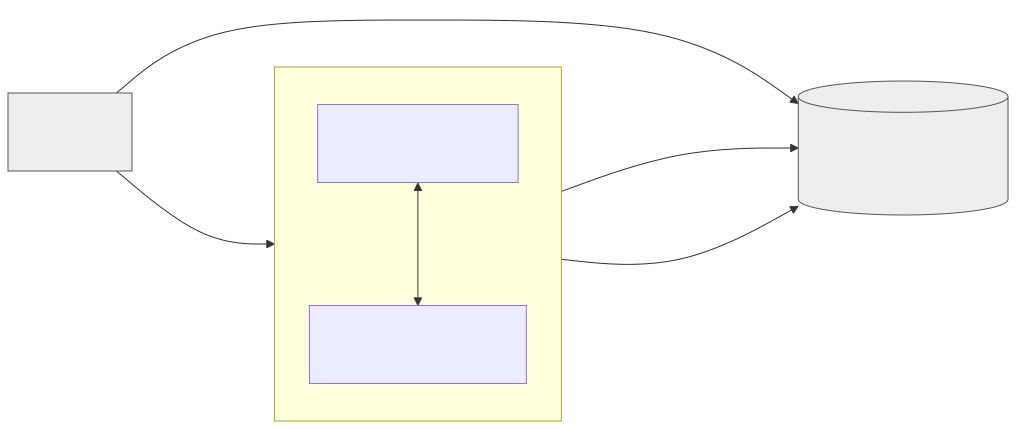

In [ ]:
CONTEXT = """
flowchart LR
    U["<b>Browser</b><br/>two tabs"]
    subgraph FL["<b>firelab</b> — Python, FastAPI, port 8090"]
        direction TB
        UI["Svelte control panel<br/><i>ui/dist</i>"]
        ENG["Engine<br/><i>simulation + decisions</i>"]
    end
    BS[("<b>BuildSim</b> — Go, port 9090<br/>floor plans, walkable graph,<br/>router, 3D viewer")]

    U -->|"tab 1: control"| UI
    UI <-->|"REST commands<br/>SSE snapshots"| ENG
    ENG -->|"GET floors, stairs, routes"| BS
    ENG -->|"PUT layers, effects, alerts,<br/>doors, people, sensors"| BS
    U -->|"tab 2: watch"| BS

    classDef truth fill:#fde2e2,stroke:#c0392b,color:#000
    classDef sense fill:#fff4d6,stroke:#b7950b,color:#000
    classDef brain fill:#dde8fb,stroke:#2e5cb8,color:#000
    classDef act fill:#dff5e3,stroke:#1e8449,color:#000
    classDef ext fill:#eeeeee,stroke:#555,color:#000

    class BS,U ext
"""

mermaid(CONTEXT)

| Process | Stack | Port | Responsible for |
|---|---|---|---|
| **BuildSim** | Go (`../buildingsim`) | 9090 | floor plans, walkable graph, multi-floor router, equipment tree, 3D viewer |
| **firelab** | Python 3.10, FastAPI + uvicorn, Svelte 5 UI | 8090 | simulation, sensing, detection, response, evacuation, scoring, control UI |

What firelab **reads** from BuildSim:

| Call | Used for |
|---|---|
| `GET /healthz` | connection status |
| `GET /api/building/floors/{level}` | rooms and walkable graph for `level0`, `level1`, `level2` |
| `GET /api/building/cross-floor-edges` | stairwells joining the storeys |
| `GET /api/graph/route` | escape routes (multi-floor, avoiding blocked rooms) |
| `GET /api/sessions` | which viewer tab to draw highlights and routes into |

What it **writes** is covered in §11. firelab never changes BuildSim's code; it
only uses the public REST API, and all of those calls live in
`adapters/buildsim/client.py` and `viewer.py`.

Running it:

```bash
cd ../buildingsim && ./bin/buildsim start --port 9090   # terminal 1
cd firelab && make build && make run                     # terminal 2 → http://127.0.0.1:8090
make test                                                # 97 tests, no services needed
```

## 2. The control loop

The whole system is one feedback loop split into four zones:

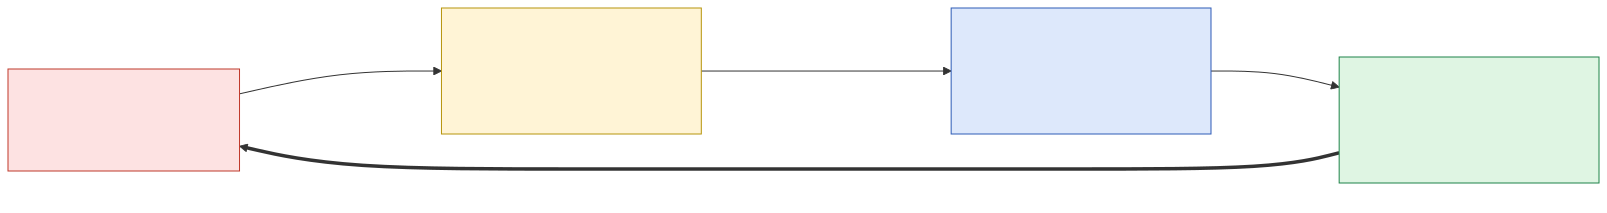

In [ ]:
LOOP = """
flowchart LR
    W["<b>1 · WORLD</b><br/>sources + physics<br/><i>what is really happening</i>"]
    S["<b>2 · SENSING</b><br/>smoke, CO, temperature devices<br/><i>late, noisy, can fail</i>"]
    I["<b>3 · INTELLIGENCE</b><br/>features → detector → agent<br/><i>is it a fire? what to do?</i>"]
    A["<b>4 · ACTION</b><br/>interlocks → sprinkler, door, evacuate<br/><i>is that command safe?</i>"]

    W -->|true heat, smoke, CO| S
    S -->|readings| I
    I -->|commands| A
    A ==>|"<b>feedback</b><br/>sprinkler cuts heat, closed door slows spread"| W

    classDef truth fill:#fde2e2,stroke:#c0392b,color:#000
    classDef sense fill:#fff4d6,stroke:#b7950b,color:#000
    classDef brain fill:#dde8fb,stroke:#2e5cb8,color:#000
    classDef act fill:#dff5e3,stroke:#1e8449,color:#000
    classDef ext fill:#eeeeee,stroke:#555,color:#000

    class W truth
    class S sense
    class I brain
    class A act
"""

mermaid(LOOP)

| Zone | May read | Produces | Code |
|---|---|---|---|
| **WORLD** | sources, previous truth, sprinkler and door state | true temperature, smoke, CO per room | `truth.advance` → `physics.step` |
| **SENSING** | the true value of its own room | noisy, lagged, possibly faulty readings | `truth.sense` → `sensing.sample` |
| **INTELLIGENCE** | readings only, **never the truth** | P(fire) per room, alarm state, commands | `intelligence.think` |
| **ACTION** | commands, plus the facts the interlocks need | sprinkler on/off, door open/closed, evacuation | `actuation.apply` |

Two points carry the design:

1. **The truth boundary.** The detector only sees what the sensors report. If it
   could read the true smoke level it would be perfect, and false alarms, missed
   fires and broken sensors would mean nothing. `app/engine/intelligence.py` holds
   the whole INTELLIGENCE zone, and a test fails if that file reads `.temperature`,
   `.smoke` or `.co`.
2. **The feedback arrow.** An allowed sprinkler command sets `space.sprinkler`, and
   the next `physics.step` cuts that room's heat release to 25 % and its smoke to
   40 %. A closed fire door lowers the `openness` of every doorway into that room
   to 0.15, which slows diffusion. What the system does changes what its sensors
   read next, so it is a control system rather than a dashboard.

## 3. Layers and the dependency rule

Inside the firelab process the code is split into three layers. Imports only point
downward.

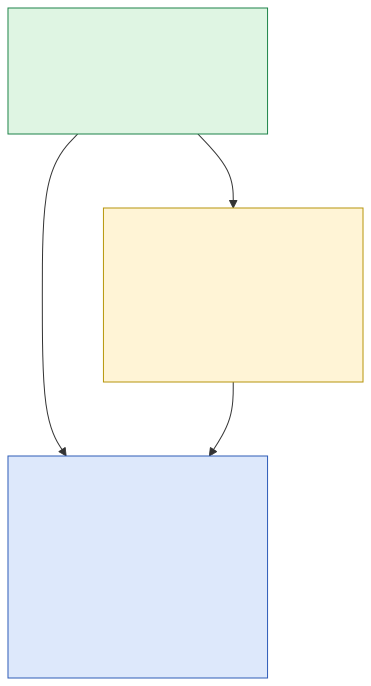

In [ ]:
LAYERS = """
flowchart TB
    APP["<b>app/</b> — impure edge<br/>tick loop, clock, locks, HTTP API, snapshot<br/><i>owns all mutable state</i>"]
    ADP["<b>adapters/</b> — BuildSim boundary<br/>HTTP client, floor plans → World, state → payloads<br/><i>the only code that imports httpx</i>"]
    DOM["<b>domain/</b> — pure core<br/>sources, physics, sensing, features, detector,<br/>agent, interlocks, occupants, tenability, scoring<br/><i>standard library only: no network, no clock</i>"]

    APP -->|imports| ADP
    APP -->|imports| DOM
    ADP -->|imports| DOM

    classDef truth fill:#fde2e2,stroke:#c0392b,color:#000
    classDef sense fill:#fff4d6,stroke:#b7950b,color:#000
    classDef brain fill:#dde8fb,stroke:#2e5cb8,color:#000
    classDef act fill:#dff5e3,stroke:#1e8449,color:#000
    classDef ext fill:#eeeeee,stroke:#555,color:#000

    class DOM brain
    class ADP sense
    class APP act
"""

mermaid(LAYERS)

| Layer | Contains | Rule |
|---|---|---|
| `domain/` | the models: `world`, `sources`, `physics`, `sensing`, `features`, `detector`, `agent`, `interlocks`, `roles`, `occupants`, `tenability`, `scoring`, `timeline`, `history` | imports only `collections`, `dataclasses`, `enum`, `math`, `random`, `typing`. No network, no clock, no config. Time and randomness are passed in. |
| `adapters/` | `buildsim/` (transport, client, viewer sessions), `world_builder.py` (floor plans → `World`), `publisher/` (state → BuildSim payloads) | the only code that imports `httpx`. Holds no simulation state. |
| `app/` | `engine/` (state + tick loop), `evacuation.py`, `api/` (routers), `snapshot/` (state → UI JSON), `config.py`, `presets.py`, `main.py`, `runtime.py` | owns the one mutable `Engine`, the clock, and the HTTP surface. |

`tests/test_layering.py` checks all three rules by parsing the source with `ast`:

| Test | Checks |
|---|---|
| `test_domain_is_pure` | every `domain/*.py` imports only the allowed standard-library modules |
| `test_intelligence_never_reads_the_truth` | `app/engine/intelligence.py` never reads `temperature`, `smoke` or `co` |
| `test_only_adapters_talk_to_buildsim` | nothing outside `adapters/` imports `httpx` |

Because of this layering, every domain module can be unit-tested with nothing
running, and the whole suite finishes in about 1.6 s.

### Module map

```
firelab/
  domain/                pure models
    world.py               Space, Coupling, World; T_OUT = 20 °C; 1 plan unit = 0.5 m
    sources.py             Source and emission(): what each kind of source gives off over time
    physics.py             step(): relaxation towards equilibrium + door-gated diffusion
    sensing.py             Device and sample(): lag, bias, noise, quantisation, clamp, faults
    features.py            Window (120 s of readings) and extract() → Features
    detector.py            Detector protocol, FusionRule baseline
    agent.py               RoomAgent state machine, Command, Thresholds
    interlocks.py          check(): safety vetoes on commands
    roles.py               five occupant roles and the default population
    occupants.py           place() people, advance() them along a route
    tenability.py          ISO 13571 escape limits, CO dose (FED)
    scoring.py             detections, misses, false alarms
    timeline.py            ignition → alarm → building empty (RSET)
    history.py             240-sample rolling record per room
  adapters/
    buildsim/transport.py  one httpx pool, every failure → BuildSimError
    buildsim/client.py     one method per BuildSim URL
    buildsim/viewer.py     finds the active viewer tab; highlights, route
    world_builder.py       floor plans + stairs → World
    publisher/             layers, effects, beliefs, people, hardware, routes
  app/
    main.py                FastAPI app, routers, serves ui/dist
    runtime.py             the single Engine instance
    config.py              runtime settings (editable over HTTP)
    presets.py             six one-click scenarios
    evacuation.py          route lookup (BuildSim) and walking
    engine/                state, core (tick loop), building, session, scenario,
                           devices, truth, intelligence, actuation, recording,
                           publishing, streaming, constants
    snapshot/              builder, status, spaces, safety, population, explain
    api/                   system, events, clock, scenario, population,
                           sensors, response, data, models
  ui/                      Svelte 5 + Vite; src/lib has one component per panel
  tests/                   15 test files
```

## 4. Startup and one tick

### 4.1 Startup

`app/main.py` ties the engine's lifetime to the server's. On boot, `engine.start()`
calls `building.load()` and then starts the background loop.

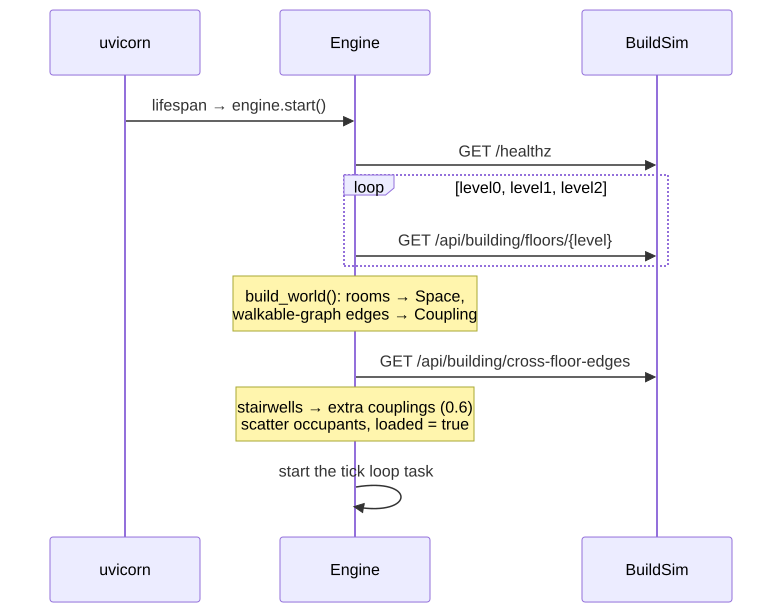

In [ ]:
STARTUP = """
sequenceDiagram
    participant U as uvicorn
    participant E as Engine
    participant B as BuildSim
    U->>E: lifespan → engine.start()
    E->>B: GET /healthz
    loop level0, level1, level2
        E->>B: GET /api/building/floors/{level}
    end
    Note over E: build_world(): rooms → Space,<br/>walkable-graph edges → Coupling
    E->>B: GET /api/building/cross-floor-edges
    Note over E: stairwells → extra couplings (0.6)<br/>scatter occupants, loaded = true
    E->>E: start the tick loop task
"""

mermaid(STARTUP)

If BuildSim is unreachable, `connected` stays false, an error goes into the journal,
and the loop idles until `POST /api/reload` is called. If a floor fails to load,
the others still load. If the stairwell call fails, each floor still works on its
own, but smoke and people cannot move between storeys.

### 4.2 One tick

`Engine._loop()` wakes every **0.25 s** (`REAL_TICK`). If the building is loaded and
the clock is running, it takes `engine.lock` and runs `_tick(elapsed × factor)`:

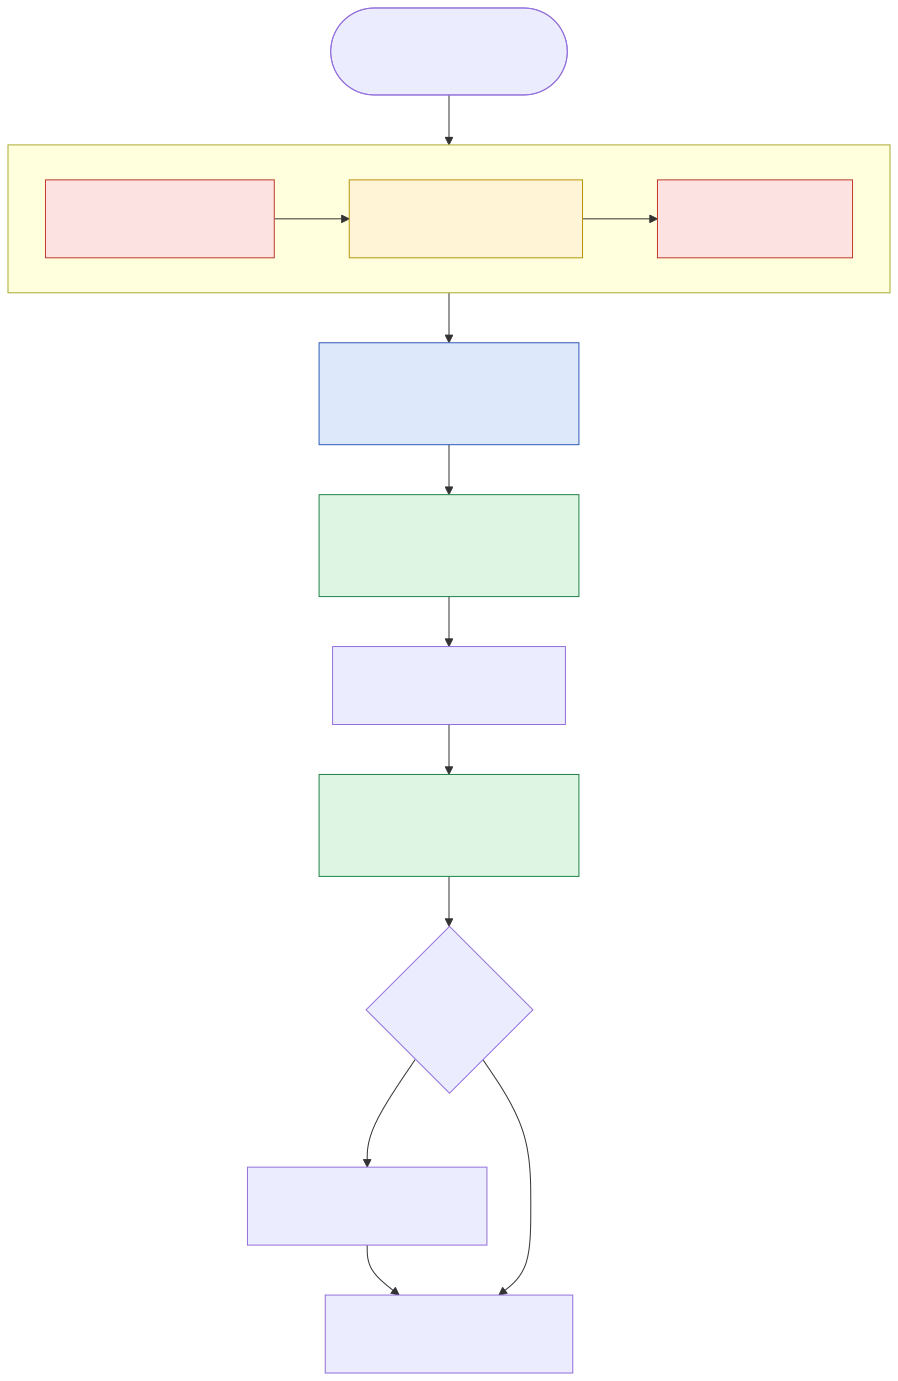

In [ ]:
TICK = """
flowchart TB
    START(["every 0.25 s of wall clock<br/>simulated = elapsed × speed factor"])
    subgraph SUB["repeated in ≤ 60 sub-steps of ~1 simulated second"]
        direction LR
        ADV["<b>truth.advance</b><br/>sources → physics.step"]
        SEN["<b>truth.sense</b><br/>devices sample the truth"]
        EXP["<b>truth.expose</b><br/>people breathe CO"]
        ADV --> SEN --> EXP
    end
    THINK["<b>intelligence.think</b><br/>features → P(fire) → agent → score"]
    APPLY["<b>actuation.apply</b><br/>each command → interlocks → act"]
    REC["<b>recording.record</b><br/>truth + reading every 5 s"]
    EVAC["<b>evacuation.plan + advance</b><br/>route and walk occupants"]
    PUB{"≥ 1 s since<br/>last publish?"}
    SEND["<b>publishing.publish</b><br/>parallel PUTs to BuildSim"]
    SSE["<b>broadcast</b><br/>snapshot to every browser"]

    START --> SUB --> THINK --> APPLY --> REC --> EVAC --> PUB
    PUB -->|yes| SEND --> SSE
    PUB -->|no| SSE

    classDef truth fill:#fde2e2,stroke:#c0392b,color:#000
    classDef sense fill:#fff4d6,stroke:#b7950b,color:#000
    classDef brain fill:#dde8fb,stroke:#2e5cb8,color:#000
    classDef act fill:#dff5e3,stroke:#1e8449,color:#000
    classDef ext fill:#eeeeee,stroke:#555,color:#000

    class ADV,EXP truth
    class SEN sense
    class THINK brain
    class APPLY,EVAC act
"""

mermaid(TICK)

| Step | Code | Detail |
|---|---|---|
| sub-stepping | `core._tick` | the simulated interval is split into `count = clamp(simulated / step_seconds, 1, 60)` equal steps (`step_seconds` = 1 s), so fast-forwarding does not destabilise the physics |
| WORLD | `truth.advance` | sums the emissions of all sources per room, then `physics.step(world, emissions, dt)` |
| SENSING | `truth.sense` | each device samples its room's true value; each reading goes into that room's `Window` and into `pending_writes` for BuildSim |
| exposure | `truth.expose` | every occupant still inside adds a CO dose from their room's **true** CO |
| INTELLIGENCE | `intelligence.think` | once per tick (not per sub-step): features, P(fire), agent update, scoreboard update |
| ACTION | `actuation.apply` | every proposed command is checked by the interlocks and applied if allowed |
| recording | `recording.record` | truth beside reading for monitored rooms, at most every 5 simulated seconds |
| evacuation | `evacuation.plan` / `advance` | re-plan routes against the current danger set, then walk everyone by `walking_speed × simulated seconds` |
| publishing | `publishing.publish` | only when `now − last_publish ≥ PUBLISH_EVERY × factor`, i.e. about once per wall-clock second |
| streaming | `_broadcast` | builds the snapshot once and pushes it to every open `/api/events` connection (skipped if nobody is listening) |

While paused, the loop only publishes if something changed (`dirty` is set by
deploy, actuation, re-population), so edits still show up in BuildSim.

## 5. WORLD — sources and physics

### 5.1 The building model (`world.py`, `adapters/world_builder.py`)

| Type | Fields | Built from |
|---|---|---|
| `Space` | `key` = `"level/name"`, `level`, `name`, `kind`, `area_m2`, `center`, `routable`, and the state `temperature`, `smoke`, `co`, `sprinkler` | one per named room in `floors/{level}.rooms`; area × 0.25 (plan units are 0.5 m); `volume_m3 = max(area × 3 m, 10)` |
| `Coupling` | `a`, `b`, `conductance`, `openness` (0..1) | an edge in the walkable graph whose two nodes have **different** room names is a doorway; `conductance = 1 / max(weight, 1)`, keeping the widest per pair |
| stairwell coupling | same | each `cross-floor-edge` becomes a coupling with `conductance = 0.6`, de-duplicated |
| `World` | `spaces`, `couplings` | `reset()` returns every room to 20 °C, no smoke or CO, sprinklers off, all doors fully open |

A room with no node in the walkable graph is marked `routable = False`, and no
occupants are placed in it.

### 5.2 Sources (`sources.py`)

A `Source` has `id`, `kind`, `space`, `t_start`, `growth`, `peak_kw`. The **kind is
the ground-truth label**: `flaming` and `smouldering` are real fires, and
`cooking`, `dust` and `steam` are nuisances. `emission(source, now)` returns the
heat (kW) and the smoke (1/m) and CO (ppm) levels the room would settle at, with
`e` = seconds since ignition:

| Kind | Heat (kW) | Smoke level | CO level | Signature |
|---|---|---|---|---|
| `flaming` | `Q = min(α·e², peak_kw)` | `0.06·√Q` | `4·√Q` | grows without limit until the cap |
| `smouldering` | `3·r` | `0.9·r` | `900·r` | `r = 1 − e^(−e/300)`: dense smoke, very high CO, almost no heat |
| `cooking` | `12·b` | `0.35·b` | `25·b` | `b = bump(e, 180, 900)`: warm and smoky, little CO, fades away |
| `dust` | 0 | `0.5·bump(e, 20, 120)` | 0 | smoke only |
| `steam` | 0 | `0.7·bump(e, 30, 200)` | 0 | smoke only |

`α` (kW/s²) is `slow 0.0029`, `medium 0.0117`, `fast 0.0469`, `ultrafast 0.1876`.
`bump(t, rise, fall)` rises, holds, then decays. Several sources in one room add up.

### 5.3 Physics step (`physics.py`)

Each room is a single lumped node. `step()` has two phases.

**1 — local relaxation.** With an active sprinkler, heat × 0.25 and smoke level × 0.4. Then

$$T_{target} = 20 + \min\!\left(140\cdot\left(\tfrac{Q}{V}\right)^{2/3},\ 900\right)$$

and each quantity moves towards its target with `approach(x, target, τ, dt) = target + (x − target)·e^(−dt/τ)`,
using τ = 90 s (temperature), 45 s (smoke) and 60 s (CO).

**2 — diffusion across couplings.** For every coupling with `openness > 0`:

- per-quantity share `= min(conductance × openness × dt × rate, 0.5)`, with rate `0.12` temperature, `0.35` smoke, `0.30` CO;
- all shares touching a room are summed, and each doorway is scaled so no room exchanges more than **half its gap** across all its doorways together (`MAX_SHARE`). This keeps a corridor with twenty doorways from creating smoke;
- `flow = share × (a − b)`. All exchanges are computed first and applied afterwards, so the order of couplings does not matter. Results are clamped at 20 °C and at 0 for smoke and CO.

Closing a fire door sets `openness = 0.15` on every coupling touching that room
(§8). Opening it restores 1.0.

## 6. SENSING — emulated devices

### 6.1 Deployment (`app/engine/devices.py`)

A room is only **monitored** once devices are deployed in it. `deploy(spaces, modalities)`:

- creates one `Device` per room and modality, with id `fl-<level>-<name>-<modality>`;
- applies the live settings `interval` (default 5 s) and `noise × noise_scale`;
- creates that room's `Window` and `RoomAgent`.

An unmonitored room has no readings, no P(fire) and no agent, so it can never
alarm, however hard it burns. `register()` mirrors devices into BuildSim's
equipment tree with one `POST /api/equipment/bulk`. `undeploy()` removes the
devices, window, agent, probability and features for those rooms.

### 6.2 The transducer chain (`sensing.py`)

`sample(device, truth, now, dt, rng)` runs every sub-step:

1. **lag:** `internal = approach(internal, truth, τ, dt)`, always, even between samples;
2. **sample gate:** returns `None` until `next_sample`, then schedules the next sample `interval` later;
3. **fault** (see below);
4. **bias + drift:** `internal + bias + drift`;
5. **noise:** plus a Gaussian with `σ = noise`;
6. **quantise:** rounds to `quantum`;
7. **clamp:** limits to `[low, high]`.

| Modality | τ (s) | bias | noise σ | quantum | range |
|---|---|---|---|---|---|
| smoke (1/m) | 12 | 0 | 0.010 | 0.005 | 0 – 3 |
| co (ppm) | 25 | 0 | 3.0 | 1 | 0 – 2000 |
| temperature (°C) | 30 | 0 | 0.15 | 0.1 | −20 – 250 |

| Fault | Behaviour |
|---|---|
| `none` | healthy chain |
| `dead` | never reports again; `reading = None` |
| `dropout` | skips each due sample with probability 0.4 |
| `stuck` | repeats its last value forever |
| `drift` | adds `0.02 × range / 600 × interval` per sample, so the error keeps growing |

Faults are injected with `POST /api/sensors/fault`, or by a preset. All randomness
comes from one `Random(seed)` held by the engine, so a run with a fixed seed can be
repeated exactly.

## 7. INTELLIGENCE — features, detector, agent

Everything in this section runs inside `intelligence.think()`, once per tick, and
sees only readings.

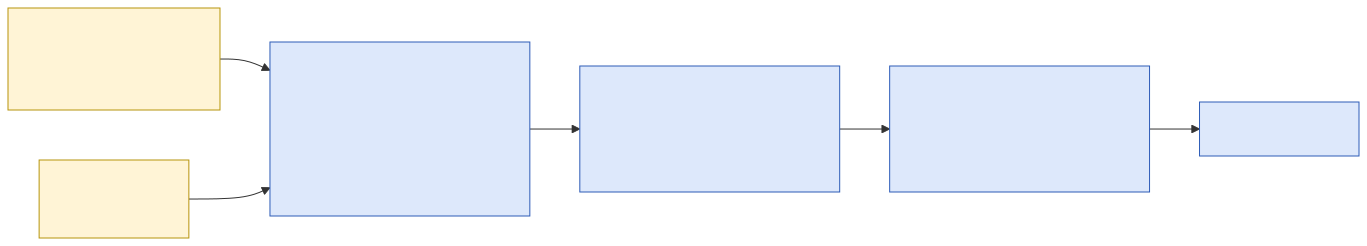

In [ ]:
DETECT = """
flowchart LR
    WIN["<b>Window</b><br/>last 120 s of readings<br/>per room"]
    NB["neighbours'<br/>latest smoke"]
    FEAT["<b>extract</b><br/>smoke, CO, temperature rise,<br/>smoke rate, CO/smoke,<br/>neighbour agreement, coverage"]
    TERMS["<b>FusionRule.explain</b><br/>one weighted term per feature<br/>+ bias −3.4"]
    P["<b>probability</b><br/>logistic(sum)<br/>× (0.55 + 0.45 × coverage/3)"]
    AG["<b>agent.update</b>"]
    WIN --> FEAT
    NB --> FEAT
    FEAT --> TERMS --> P --> AG

    classDef truth fill:#fde2e2,stroke:#c0392b,color:#000
    classDef sense fill:#fff4d6,stroke:#b7950b,color:#000
    classDef brain fill:#dde8fb,stroke:#2e5cb8,color:#000
    classDef act fill:#dff5e3,stroke:#1e8449,color:#000
    classDef ext fill:#eeeeee,stroke:#555,color:#000

    class WIN sense
    class NB sense
    class FEAT,TERMS,P,AG brain
"""

mermaid(DETECT)

### 7.1 Features (`features.py`)

`Window` keeps each modality's `(t, value)` readings for the last **120 s**. `extract(window, neighbour_smoke)` returns:

| Feature | Definition |
|---|---|
| `smoke`, `co`, `temperature` | latest reading (temperature defaults to 20 °C) |
| `temperature_rise` | `max(0, temperature − 20)` |
| `smoke_rate` | (newest − oldest smoke in the window) / span × 60, per minute |
| `co_smoke_ratio` | `co / smoke` when `smoke > 0.05`, else 0 |
| `neighbour_agreement` | fraction of **monitored** neighbours whose latest smoke reading is > 0.05 |
| `coverage` | how many of the three modalities have any reading in the window (0–3) |

Neighbour readings come from `intelligence.neighbour_readings()`, which walks the
couplings and uses only neighbours that have their own window.

### 7.2 Detector (`detector.py`)

`Detector` is a `Protocol` with `name`, `probability(features)` and
`explain(features)`. The installed implementation is `FusionRule`, a hand-written
baseline (`EngineState.detector = FusionRule()`). `explain()` returns one weighted
term per feature, and P(fire) is computed from exactly those terms:

| Term | Weighted contribution |
|---|---|
| bias | −3.4 |
| smoke | 3.2 × min(smoke, 1.5) |
| co | 1.8 × clamp((co − 25) / 125, 0, 1) |
| co_smoke_ratio | 1.6 × min(ratio / 250, 2.5) × min(smoke / 0.15, 1) |
| temperature_rise | 0.55 × min(rise, 60) / 10 |
| smoke_rate | 1.4 × clamp(rate, 0, 1) |
| neighbour_agreement | 0.8 × agreement |

$$P(\text{fire}) = \text{logistic}\Big(\sum \text{terms}\Big) \times \Big(0.55 + 0.45\cdot\tfrac{\min(\text{coverage},3)}{3}\Big)$$

With no working sensor (`coverage = 0`), P is 0. With one modality, P can reach at
most 0.70, below the 0.75 confirm threshold, so **one sensor alone can never confirm
a fire**. The CO term is not divided by smoke, so it still counts when the smoke
detector is dead. The UI's "Why" panel draws the same `explain()` terms
(`GET /api/history` → `why`).

### 7.3 Agent state machine (`agent.py`)

One `RoomAgent` per monitored room. `update(agent, p, now, thresholds)` moves at
most one step per tick. The thresholds come from `config.response` and can be
changed live:

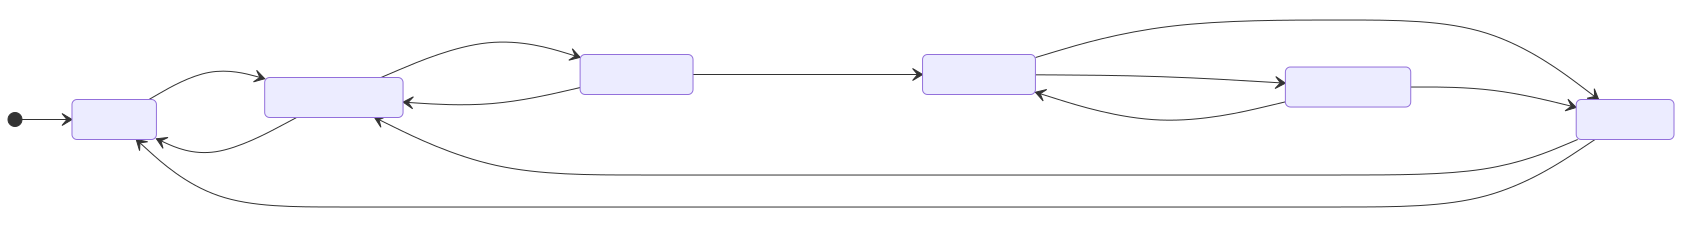

In [ ]:
STATES = """
stateDiagram-v2
    direction LR
    [*] --> NORMAL
    NORMAL --> INVESTIGATING: p ≥ 0.35
    INVESTIGATING --> NORMAL: p < 0.25
    INVESTIGATING --> PRE_ALARM: p ≥ 0.55 held 20 s
    PRE_ALARM --> INVESTIGATING: p < 0.35
    PRE_ALARM --> CONFIRMED: p ≥ 0.75 and 25 s in state
    CONFIRMED --> SUPPRESSED: sprinkler on and p < 0.75 for 25 s
    SUPPRESSED --> CONFIRMED: p ≥ 0.75
    CONFIRMED --> CLEARING: p ≤ 0.25 for 90 s
    SUPPRESSED --> CLEARING: p ≤ 0.25 for 90 s
    CLEARING --> INVESTIGATING: p ≥ 0.35
    CLEARING --> NORMAL: 90 s in state
"""

mermaid(STATES)

| Threshold | Default | Meaning |
|---|---|---|
| `investigate` | 0.35 | start watching |
| `pre_alarm` | 0.55 | must be held continuously for `dwell_pre_alarm` = 20 s |
| `confirm` | 0.75 | PRE_ALARM must have lasted `dwell_confirm` = 25 s |
| `clear` | 0.25 | must be held for `dwell_clear` = 90 s to stand down |

Commands are tied to **entering** a state:

| Entering | Commands |
|---|---|
| `CONFIRMED` | `sprinkler=on`, `fire_door=closed`, `evacuate=start` |
| `CLEARING` | `sprinkler=off`, `fire_door=open`, `evacuate=stop` |
| `SUPPRESSED` | none. CONFIRMED's outstanding commands stay pending |
| any other state | clears the pending list |

Commands live in `agent.pending`, and `update()` returns the whole list **every
tick** until `retire()` removes one. That happens only when a command is actually
carried out, whether it came from the agent or an operator. So a command the
interlocks refuse is delayed, not lost. `retire()` of `sprinkler=on` sets
`suppressing = True`, which is what allows `CONFIRMED → SUPPRESSED`.

After the agents, `think()` updates the scoreboard (§10) and returns the commands.
In supervised mode (`config.response.auto = False`) the commands are dropped
instead of returned. The agent still changes state, and its commands stay
pending until an operator issues them.

## 8. ACTION — interlocks and actuation

`actuation.apply(engine, command, manual)` is the only place anything physical
changes. Agent commands and operator overrides (`POST /api/actuators/command`) both
go through it, so clicking a button cannot bypass an interlock.

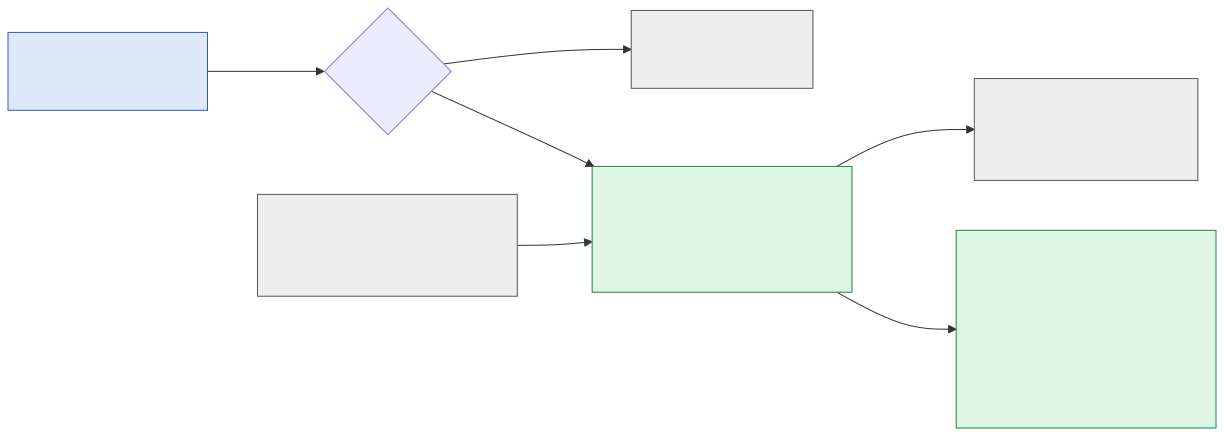

In [ ]:
ACTUATE = """
flowchart LR
    AG["<b>agent</b><br/>pending commands"]
    MODE{"auto<br/>mode?"}
    DROP["dropped<br/><i>supervised mode</i>"]
    BTN["<b>operator</b><br/>POST /api/actuators/command"]
    CHK["<b>interlocks.check</b><br/>true temperature · occupants in room<br/>· room on an escape route"]
    NO["<b>refused</b><br/>journal entry; the agent<br/>offers it again next tick"]
    YES["<b>carried out</b><br/>sprinkler → space.sprinkler<br/>fire door → coupling openness 1.0 / 0.15<br/>evacuate → everyone inside starts walking<br/>then agent.retire()"]

    AG --> MODE
    MODE -->|yes| CHK
    MODE -->|no| DROP
    BTN --> CHK
    CHK -->|refused| NO
    CHK -->|allowed| YES

    classDef truth fill:#fde2e2,stroke:#c0392b,color:#000
    classDef sense fill:#fff4d6,stroke:#b7950b,color:#000
    classDef brain fill:#dde8fb,stroke:#2e5cb8,color:#000
    classDef act fill:#dff5e3,stroke:#1e8449,color:#000
    classDef ext fill:#eeeeee,stroke:#555,color:#000

    class AG brain
    class CHK,YES act
    class BTN,DROP,NO ext
"""

mermaid(ACTUATE)

### 8.1 Interlocks (`interlocks.py`)

`check(command, temperature, occupants, on_escape_route)` returns a `Verdict(allowed, reason)`:

| Command | Rule |
|---|---|
| `sprinkler=on` | refused if the room's temperature is **below 35 °C** ("smoke alone does not release water") |
| `fire_door=locked` | always refused ("fire doors fail unlocked") |
| `fire_door=closed` | refused if the room is on any occupant's remaining route, or if anyone is still inside |
| anything else | allowed (`sprinkler=off`, `fire_door=open`, `evacuate=start/stop`) |

The engine supplies the inputs: `temperature` is the room's **true** temperature,
standing in for a heat-activated sprinkler head. `occupants` counts people in the
room who are not yet safe. `on_escape_route` is true if the room appears in any
occupant's `route_spaces`.

### 8.2 Effects (`app/engine/actuation.py`)

| Allowed command | Effect |
|---|---|
| `sprinkler=on/off` | `space.sprinkler = True/False`, which physics reads on the next step |
| `fire_door=closed/open` | `engine.doors[space]` is set, and every coupling touching the room gets `openness = 0.15` (closed) or `1.0` (open) |
| `evacuate=start` | **every** occupant still inside gets status `evacuating`: one confirmed room evacuates the whole building |
| `evacuate=stop` | everyone goes back to `idle`, but only if no room is still in danger |

Refusals are written to the journal only when the reason changes, so a command
retried every tick does not flood the log. `danger(engine)` is the set of rooms in
`PRE_ALARM`, `CONFIRMED` or `SUPPRESSED`; evacuation and the published door states
both use it.

## 9. Occupants and evacuation

### 9.1 People (`roles.py`, `occupants.py`)

| Role | Default count | Speed factor | Note |
|---|---|---|---|
| student | 28 | 1.05 | quick, but only know the main entrance |
| lecturer | 5 | 1.00 | know the building |
| staff | 4 | 1.00 | technical and administrative staff |
| security | 1 | 1.15 | drilled on the escape routes |
| visitor | 2 | 0.85 | have never been here before |

`place()` scatters people at random over routable rooms that are not corridors and
are larger than 8 m². Each person gets a permanent offset of up to ±2.5 plan units,
so people at the same waypoint are not drawn on top of each other. The mix is
changed with `PUT /api/population` (at most 2000 people).

`advance(occupant, budget)` walks along the waypoints and updates `occupant.space`
as each waypoint is reached. A person is `safe` when no waypoints are left.

### 9.2 Routing (`app/evacuation.py`)

`Evacuation.plan()` runs every tick while any room is in danger:

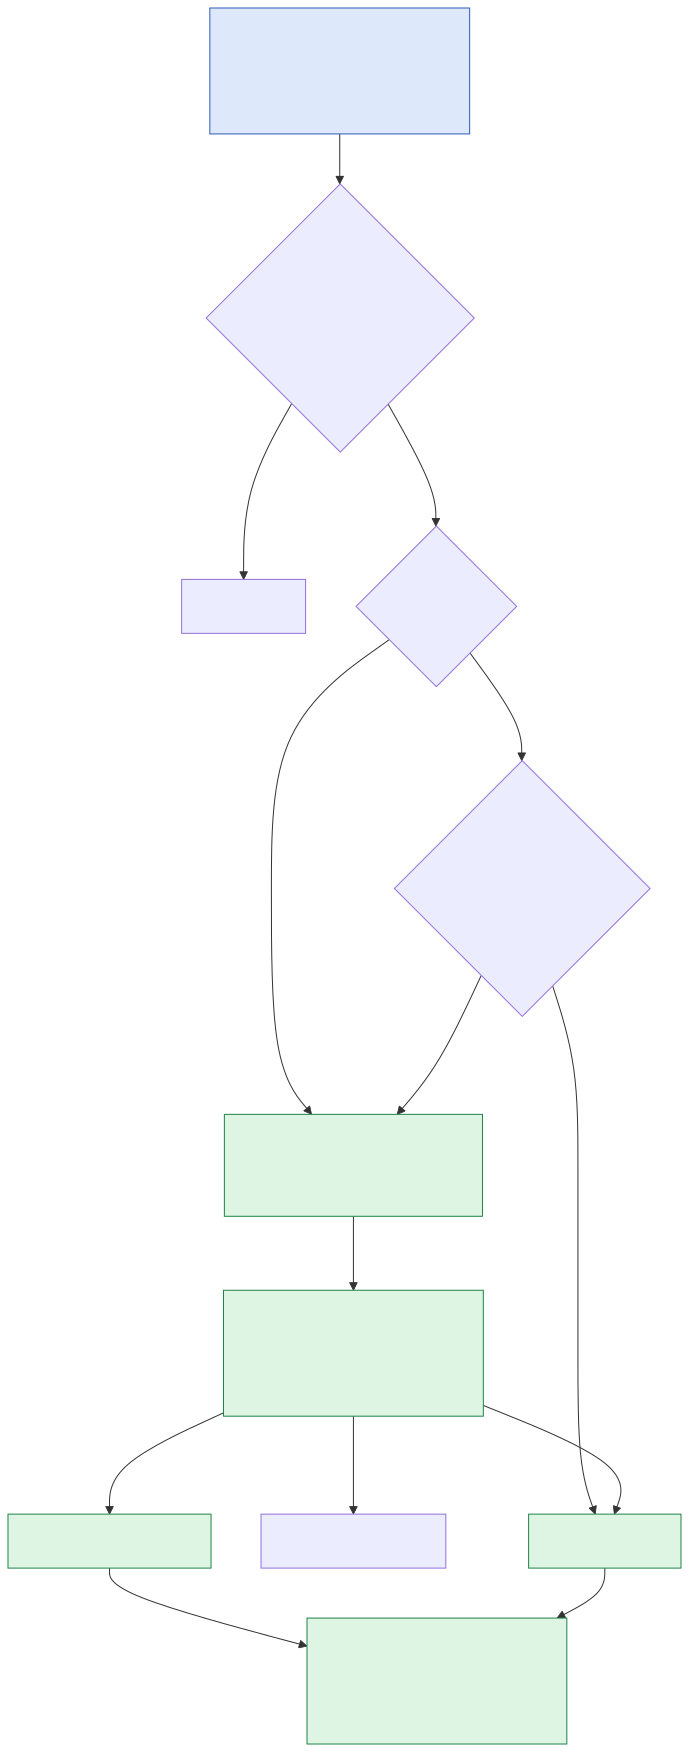

In [ ]:
EVAC = """
flowchart TB
    D["<b>danger</b> = rooms in PRE_ALARM,<br/>CONFIRMED or SUPPRESSED"]
    WHO{"occupant in a danger room<br/>or already evacuating?"}
    SKIP["stays put"]
    HAS{"already has<br/>a route?"}
    CLEAR{"does the rest of the route<br/>cross a danger room?"}
    KEEP["keep walking"]
    ASK["ask BuildSim for a route to<br/><b>every exit</b> not in danger<br/>(multi-floor graph, via stairs)"]
    RANK["rank: fewest danger rooms crossed,<br/>then length + 20 per storey change"]
    NONE["status = <b>no route</b>"]
    SET["follow the best route"]
    WALK["advance: 1.3 m/s × role speed<br/>safe when last waypoint reached"]

    D --> WHO
    WHO -->|no| SKIP
    WHO -->|yes| HAS
    HAS -->|no| ASK
    HAS -->|yes| CLEAR
    CLEAR -->|no| KEEP
    CLEAR -->|"yes: only switch if the new<br/>route crosses fewer"| ASK
    ASK --> RANK
    RANK -->|"nothing found<br/>(no current route)"| NONE
    RANK -->|"better than current"| SET --> WALK
    RANK -->|"not better"| KEEP
    KEEP --> WALK

    classDef truth fill:#fde2e2,stroke:#c0392b,color:#000
    classDef sense fill:#fff4d6,stroke:#b7950b,color:#000
    classDef brain fill:#dde8fb,stroke:#2e5cb8,color:#000
    classDef act fill:#dff5e3,stroke:#1e8449,color:#000
    classDef ext fill:#eeeeee,stroke:#555,color:#000

    class D brain
    class ASK,RANK,SET,WALK,KEEP act
"""

mermaid(EVAC)

- **Exits** are the real ground-floor doors listed in `config.exits`
  (`level0`: `A1016, A1123, A105, A10, A1000A, A1000E, A170`). People on upper floors
  are routed down the stairs to one of these.
- **Route requests** go to `GET /api/graph/route` with `from_level` and `to_level`,
  which selects BuildSim's merged multi-floor graph. An exit that is itself in danger
  is never a candidate.
- **Ranking** is `(danger rooms crossed, excluding the starting room; path length + 20 per change of storey)`.
  A clear route always wins, but a smoky route is still better than none, because
  one corridor is often the only way out of a wing.
- **Caching:** the best route from each starting room is cached together with the
  danger set it was computed against, and recomputed when that set changes.
- **Re-routing** someone already walking only happens if the new route crosses
  **fewer** danger rooms than what is left of the current one. This stops people
  jogging on the spot.
- **`no route`** means BuildSim returned no path to any exit. These people are
  reported as stranded.
- **Display route:** one route is drawn in the viewer, chosen by nearness to the
  fire (in a danger room, then next to one, then anywhere; ties broken by name).

`advance()` moves everyone who is `evacuating` by
`walking_speed (1.3 m/s) / 0.5 × simulated seconds × role speed` plan units.

BuildSim's router is also told which rooms are on fire: `publisher.doors()` sends
every danger room with `blocked: true`, and BuildSim drops the entry nodes of
blocked rooms. Corridors have no entry nodes, which is why firelab also does its
own hazard ranking.

## 10. Life safety and evaluation

Every source carries its true kind, so the run is graded while it happens.

### 10.1 Tenability (`tenability.py`)

These are escape thresholds after ISO 13571. `assess(temperature, smoke)` marks a room
**untenable** when temperature ≥ **60 °C** or smoke ≥ **0.30 /m** (visibility
`3 / smoke` ≈ 10 m).

Each occupant still inside builds up a CO dose every sub-step:
`fed += co^1.036 / 35000 × dt / 60`. Someone with `fed ≥ 0.3` counts as
**incapacitated**, including people who later reach an exit. The snapshot reports
untenable rooms (occupied rooms first), people exposed, people incapacitated, and
the worst dose.

### 10.2 Scoring (`scoring.py`)

`Scoreboard.update()` runs every tick after the agents:

| Outcome | Rule |
|---|---|
| **detection** | a room newly enters `CONFIRMED`/`SUPPRESSED` while a real source (`flaming`/`smouldering`) is lit in it; latency = now − ignition |
| **excused** | no source in the room, but a real fire is lit in an **adjacent** room (smoke came through the door) |
| **false alarm** | any other new alarm; the cause is the nuisance kind in the room, or `none` |
| **miss** | a real source lit more than **300 s** ago and not yet detected |

Each alarm is judged once, when it is raised. The summary reports counts, mean
and worst latency, and the last five false alarms.

### 10.3 Timeline (`timeline.py`)

| Metric | Measured |
|---|---|
| `alarm_delay` | first real ignition → first alarm |
| `rset` | first real ignition → building empty |
| `rset_from_alarm` | first alarm → building empty |

"Building empty" only counts if someone actually started evacuating.

### 10.4 History and export (`history.py`, `recording.py`, `api/data.py`)

Every **5 simulated seconds**, `recording.record()` stores one row per monitored
room: `t, truth_temperature, truth_smoke, truth_co, read_temperature, read_smoke, read_co, p_fire`.
Each room keeps its last **240** rows (about 20 minutes). This is the only place
that deliberately stores truth and reading side by side.

- `GET /api/history?space=` returns one room's rows plus the detector's `why` terms (the UI charts).
- `GET /api/export.csv` returns every row with `space, level, room, label` in front. The
  label is the kind of source placed in that room, or `none`, ready for training a
  model offline.

## 11. Publishing to BuildSim

`publishing.publish()` runs about once per wall-clock second. `adapters/publisher/`
builds the payloads (pure functions), and all the calls are sent together with
`asyncio.gather`:

| Endpoint | Builder | Content |
|---|---|---|
| `PUT /api/room-layers` | `layers.room_layers` | four floor heat maps: true temperature, true smoke, true CO (source *simulation truth*) and **P(fire)** (source *decision-service estimate*), so truth and belief can be compared on screen |
| `PUT /api/effects` | `effects.effects` | `fire` in rooms with a flaming/smouldering/cooking source and smoke > 0.05; `sprinkler` where active; `smoke` for the 40 smokiest rooms above 0.08 /m |
| `PUT /api/alerts` | `beliefs.alerts` | one alert per non-NORMAL room (info / warning / critical), at most 100 |
| `PUT /api/doors` | `hardware.doors` | a fire door per commanded or danger room; `lock_state` is always `unlocked`; danger rooms are `blocked` |
| `PUT /api/entities` | `people.entities` | occupants still inside (at most 2000), positions clamped to the floor page, with a 1000 ms glide |
| `PUT /api/occupancy` | `people.occupancy` | people per room |
| `PUT /api/sessions/{id}/highlights` | `beliefs.highlights` | room outlines by state (red CONFIRMED/SUPPRESSED, orange PRE_ALARM, yellow INVESTIGATING, green CLEARING); **only sent when changed** |
| `PUT /api/sessions/{id}/route` | `routes.route` | the display escape route, with distance in metres and the storey on each node; **only sent when changed** |
| `PUT /api/sensors/{id}/value` | `publishing.sensor_writes` | at most **24** pending readings per publish |
| `POST /api/equipment/bulk` | `hardware.equipment` | on deploy only: one equipment item per device |

The viewer session is the most recently active tab in `GET /api/sessions`, looked
up again every 30 s. If any call fails with `BuildSimError`, the engine is marked
disconnected and publishing stops until `POST /api/reload` reconnects.

## 12. HTTP API, snapshot and UI

### 12.1 Routes (`app/api/`)

Request bodies are Pydantic models in `api/models.py`.

| Method | Path | Router | Does |
|---|---|---|---|
| GET | `/healthz` | system | `{ok, buildsim: connected}` |
| GET | `/api/state` | system | full snapshot |
| GET | `/api/rooms` | system | every space, for pickers |
| GET / PUT | `/api/config` | system | read / patch settings (a new `seed` restarts the RNG) |
| POST | `/api/reload` | system | reload floor plans from BuildSim |
| GET | `/api/events` | events | Server-Sent Events: snapshot on connect, on every tick, and at least every 5 s |
| POST | `/api/clock` | clock | `{seconds?, factor?, running?}`; factor clamped to 0.1–600 |
| POST | `/api/reset` | clock | reset the run (§14) |
| POST | `/api/scenario/ignite` | scenario | `{space, kind, growth, delay, peak_kw}` |
| POST | `/api/scenario/preset` | scenario | `{preset, space}` |
| DELETE | `/api/scenario/{id}` | scenario | remove a source |
| GET | `/api/presets` | scenario | preset catalogue |
| GET | `/api/roles` | population | the five roles |
| PUT | `/api/population` | population | `{population: {role: count}}` and re-scatter |
| POST | `/api/sensors/deploy` | sensors | `{spaces, modalities}`, then register in BuildSim |
| POST | `/api/sensors/undeploy` | sensors | `{spaces}` |
| POST | `/api/sensors/fault` | sensors | `{device_id, fault}` |
| POST | `/api/agent/mode` | response | `{auto}`: autonomous vs supervised |
| POST | `/api/actuators/command` | response | `{kind, space, value}`, still interlocked |
| GET | `/api/history?space=` | data | one room's recorded rows + `why` |
| GET | `/api/export.csv` | data | whole run, labelled |

`GET /` serves the built UI from `ui/dist` when it exists.

### 12.2 Snapshot (`app/snapshot/builder.py`)

The UI never computes simulation values; everything it shows comes from this one dictionary:

| Key | Built by | Contains |
|---|---|---|
| `clock` | `status.clock` | seconds, `hh:mm:ss`, running, factor |
| `buildsim` | `status.buildsim` | url, connected, loaded, levels, space count |
| `detector`, `auto` | builder | installed detector name, response mode |
| `spaces` | `spaces.spaces` | one row per watched room (monitored, has a source, or P > 0.05): truth, reading, P(fire), state (`UNMONITORED` if no agent), tenable, sprinkler, door, occupants, devices |
| `sources` | builder | all sources |
| `counts` | `status.counts` | devices, faulty, alarms, evacuating, safe, occupants |
| `population` | `population.population` | per role: total, safe, evacuating, stranded |
| `tenability` | `safety.tenability_report` | §10.1 |
| `score` | `Scoreboard.summary` | §10.2–10.3 |
| `evacuation` | `safety.evacuation` | per level inside/evacuating/safe/stranded, stranded list |
| `journal` | builder | last 40 log lines |

`streaming.Broadcaster` gives each SSE connection a queue of 4 snapshots. If a
browser falls behind, its oldest snapshot is dropped, so a slow client never holds
up the engine.

### 12.3 UI (`ui/`)

Svelte 5 (runes) built with Vite. `src/lib/store.svelte.js` is the single store.
It fetches rooms, presets, roles and config once, then opens one `EventSource`
on `/api/events` and replaces `store.snapshot` on every message. User actions go
through the `api` object, one function per endpoint. `App.svelte` lays out three
columns:

| Left | Centre | Right |
|---|---|---|
| ScenarioPanel, Scorecard, EvacuationPanel, PopulationPanel, SensorPanel | RoomTable, RoomDetail (charts + Why) | ResponsePanel, TenabilityPanel, SettingsPanel, Journal |

## 13. Configuration and presets

### 13.1 `Config` (`app/config.py`)

All fields can be changed at runtime with `PUT /api/config`. `apply()` merges a
partial patch and ignores unknown keys.

| Field | Default |
|---|---|
| `buildsim_url` | `http://127.0.0.1:9090` |
| `levels` | `level0, level1, level2` |
| `factor` | 1.0 simulated s per real s |
| `step_seconds` | 1.0 |
| `seed` | 1 |
| `population` | see §9.1 |
| `walking_speed` | 1.3 m/s |
| `sensors` | `noise_scale 1.0`, `interval 5.0`, `modalities [smoke, co, temperature]` |
| `response` | `auto true` and the agent thresholds from §7.3 |
| `exits` | the seven `level0` doors from §9.2 |

`interval` and `noise_scale` apply to devices deployed **after** the change.

### 13.2 Presets (`app/presets.py`)

`apply_preset(preset, space)` deploys all three modalities in the room **and its
neighbours** (so neighbour agreement works), puts the preset's fault on that room's
smoke detector, then ignites the source.

| Id | Source | Fault | Expected outcome |
|---|---|---|---|
| `office-fire` | flaming, fast | — | detected quickly |
| `overnight-smoulder` | smouldering | — | detected on CO; sprinkler refused for lack of heat |
| `kitchen-cooking` | cooking | — | no alarm |
| `dust-storm` | dust | — | no alarm |
| `blind-spot` | flaming, fast | smoke `dead` | still detected on CO + heat, but later |
| `drifting-sensor` | none | smoke `drift` | no alarm |

`tests/test_presets.py` runs every preset end to end and checks these outcomes.

## 14. State, concurrency and reset

**State.** All mutable data lives in one `EngineState` (`app/engine/state.py`):
world, sources, devices, windows, features, probabilities, agents, occupants,
doors, blocked-command log, journal (last 200), scoreboard, history, RNG, and
publishing bookkeeping. `Engine` (`core.py`) extends it with the lifecycle and the
loop. The other engine modules are functions that take the engine as their first
argument. `app/runtime.py` creates the single instance that every router imports.

**Concurrency.** Everything runs on one asyncio event loop. The tick holds
`engine.lock`, and so does the paused publish. API handlers do not take the lock.
Most of them change state without awaiting anything, so they cannot run in the
middle of a physics step. The few that do await BuildSim (`deploy`/`preset`
registration, `reload`) can interleave with a tick at those await points.

**Simulated time** starts at 08:00:00 (`now = 28800`). It only advances while
running, by wall-clock elapsed × `factor`.

**Reset vs reload:**

| | `POST /api/reset` (`session.reset`) | `POST /api/reload` (`building.load`) |
|---|---|---|
| building / floor plans | kept | re-fetched from BuildSim, world rebuilt |
| deployed devices | kept, but readings, drift and **faults cleared** | kept in memory (ids still refer to room keys) |
| physics state, doors, sprinklers | cleared (`world.reset`) | fresh world |
| sources, probabilities, features, windows | cleared | unchanged |
| agents | back to NORMAL, pending cleared | unchanged |
| score, history, evacuation cache, journal | score/history/cache cleared | unchanged |
| occupants | re-scattered | re-scattered |
| settings | kept | kept |

`tests/test_reset.py` checks the reset column.

## 15. Tests

`make test` runs `pytest tests`: **97 tests** (plus 82 sub-tests), all passing, in
about 1.6 s. None of them need BuildSim, because the evacuation tests use a fake
client.

| File | Tests | Covers |
|---|---|---|
| `test_layering.py` | 3 | the three layer rules (§3) |
| `test_sources.py` | 3 | flaming growth and cap, smoulder signature, nuisances emit no CO |
| `test_physics.py` | 6 | spread to neighbours, sprinkler suppression, no smoke created, no room gives away more than it has, result independent of clock speed |
| `test_multifloor.py` | 10 | stairwell couplings, de-duplication, smoke climbing stairs, cross-floor routes |
| `test_sensing.py` | 3 | lag then tracking, dead, stuck |
| `test_detector.py` | 6 | quiet room, no coverage, fire vs dust, smoulder via CO, cooking below pre-alarm |
| `test_agent.py` | 5 | escalation, transients never confirm, pending commands re-offered, SUPPRESSED, return to NORMAL |
| `test_interlocks.py` | 3 | smoke alone never releases water, doors never lock, no sealing occupied rooms or routes |
| `test_publisher_doors.py` | 8 | blocked flags, never locked, stable order |
| `test_occupants.py` | 2 | placement, walking to safety |
| `test_evacuation.py` | 24 | route choice, hazard ranking, caching, re-routing, stranded people, display route |
| `test_scoring.py` | 5 | detection latency, false alarms, misses, neighbour excuse |
| `test_history.py` | 1 | rate limit and bound |
| `test_presets.py` | 9 | every preset run through the full loop (physics → actuators) |
| `test_reset.py` | 9 | what reset clears and what it keeps |

## 16. Known limitations

These are facts about the current code, not future plans:

- **The detector is a hand-written rule.** No trained model exists. `Detector` is a
  protocol, and replacing `FusionRule()` in `EngineState.__init__` is the one place
  a model would be installed; the CSV export provides labelled training rows.
- **No fire-spread forecast.** The response reacts to the current state only.
- **The physics is a lumped zone model**: one well-mixed node per room, fixed time
  constants, a 3 m ceiling, no smoke layer or flashover dynamics beyond the 900 °C cap.
- **The sprinkler interlock reads the true temperature**, not a sensor reading. This
  is intended to model a heat-activated head, but it is a second consumer of truth
  outside SENSING.
- **Evacuation is building-wide.** One confirmed room evacuates everyone, and there
  is no phased evacuation.
- **Labels are per room**: the CSV label is the kind of source placed in that room,
  so smoke that drifted into a neighbour is labelled `none`.
- **History is short**: 240 samples per room (about 20 simulated minutes).
- **Reconnection is manual**: after a BuildSim failure, publishing stays off until `POST /api/reload`.
- **One building, one run**: a single `Engine` per process, no persistence between restarts.